### **Modelagem Preditiva**

In [1]:
# Importar bibliotecas necessárias
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

In [2]:
# Carregar o DataFrame tratado para a modelagem
df_modelo = pd.read_parquet('../data/processed/microdados_matriculas_tratados.parquet')

**Preparação dos dados**

In [3]:
# Consolidação da base de treino (situações conhecidas)
df_train = df_modelo[df_modelo['categoria_situacao'] != 'Em Curso'].copy()

In [4]:
# Definir as features a serem utilizadas no modelo
features = [
    'sexo', 'cor_raca', 'renda_familiar',
    'faixa_etaria', 'turno', 'tipo_curso'
]

In [5]:
# Definir X e y para a base de treino
X = df_train[features]
y = df_train['categoria_situacao'].map({'Evadidos': 1, 'Concluídos': 0, 'Concluintes': 0})

In [6]:
# Encoding das variáveis categóricas
X = pd.get_dummies(X, columns=[
    'sexo', 'cor_raca', 'renda_familiar',
    'faixa_etaria', 'turno', 'tipo_curso'
]).astype(int)

# Sanitizar nomes de colunas para compatibilidade com XGBoost
X.columns = X.columns.str.replace(r'[<>\[\],]', '_', regex=True)


In [7]:
# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [8]:
# Balanceamento da base de treino usando SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

**Modelagem - Random Forest Classifier**

In [9]:
# Treinar modelo baseline
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_resampled, y_train_resampled)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

**Modelagem - XGBoost Classifier**

In [10]:
from xgboost import XGBClassifier

ratio = (y_train_resampled == 0).sum() / (y_train_resampled == 1).sum()

model_xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    max_depth=4,
    min_child_weight=5,
    scale_pos_weight=ratio
)

model_xgb.fit(X_train_resampled, y_train_resampled)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


**Avaliação do desempenho dos modelos**

In [11]:
# Avaliar o modelo
print("\t\t\tRandom Forest - Desempenho\n")
y_pred_rf = model_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

# Matriz de confusão para ver onde o modelo erra
print(confusion_matrix(y_test, y_pred_rf))

# AUC-ROC para avaliar a capacidade do modelo em separar as classes
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]
print(f"\nAUC-ROC: {roc_auc_score(y_test, y_prob_rf):.4f}")

			Random Forest - Desempenho

              precision    recall  f1-score   support

           0       0.50      0.52      0.51       119
           1       0.79      0.78      0.78       273

    accuracy                           0.70       392
   macro avg       0.65      0.65      0.65       392
weighted avg       0.70      0.70      0.70       392

[[ 62  57]
 [ 61 212]]

AUC-ROC: 0.7045


In [12]:
# Avaliar o modelo
print("\t\t\tXGBoost - Desempenho\n")
y_pred_xgb = model_xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

# Matriz de confusão para ver onde o modelo erra
print(confusion_matrix(y_test, y_pred_xgb))

# AUC-ROC para avaliar a capacidade do modelo em separar as classes
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]
print(f"\nAUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

			XGBoost - Desempenho

              precision    recall  f1-score   support

           0       0.49      0.58      0.53       119
           1       0.80      0.73      0.76       273

    accuracy                           0.69       392
   macro avg       0.64      0.66      0.65       392
weighted avg       0.70      0.69      0.69       392

[[ 69  50]
 [ 73 200]]

AUC-ROC: 0.7235


**Análise de Importância de Variáveis**

In [13]:
# Importância das features
print("Random Forest - Importância das Features\n")
feat_imp_rf = pd.Series(model_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(feat_imp_rf.head(15))

Random Forest - Importância das Features

faixa_etaria_20 a 24 anos       0.111840
faixa_etaria_25 a 29 anos       0.057465
tipo_curso_Bacharelado          0.046278
cor_raca_Parda                  0.045751
cor_raca_Branca                 0.043936
renda_familiar_Não declarada    0.042828
sexo_M                          0.041622
tipo_curso_Tecnologia           0.041383
turno_Noturno                   0.039636
renda_familiar_0_RFP_=0_5       0.039455
tipo_curso_Licenciatura         0.038574
renda_familiar_0_5_RFP_=1       0.038411
faixa_etaria_30 a 34 anos       0.035393
sexo_F                          0.034424
renda_familiar_1_RFP_=1_5       0.033551
dtype: float64


In [14]:
# Importância das features
print("XGBoost - Importância das Features\n")
feat_imp_xgb = pd.Series(model_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(feat_imp_xgb.head(15))

XGBoost - Importância das Features

faixa_etaria_20 a 24 anos      0.257838
tipo_curso_Bacharelado         0.069494
tipo_curso_Tecnologia          0.052787
cor_raca_Não declarada         0.045629
renda_familiar_1_RFP_=1_5      0.045590
turno_Vespertino               0.045390
turno_Noturno                  0.032634
faixa_etaria_40 a 44 anos      0.031692
turno_Não se aplica            0.031456
faixa_etaria_35 a 39 anos      0.029076
turno_Matutino                 0.028125
turno_Integral                 0.027756
faixa_etaria_45 a 49 anos      0.024701
renda_familiar_0_5_RFP_=1      0.024649
renda_familiar_1_5_RFP_=2_5    0.024326
dtype: float32


**Gráfico das Matrizes de Confusão dos Modelos**

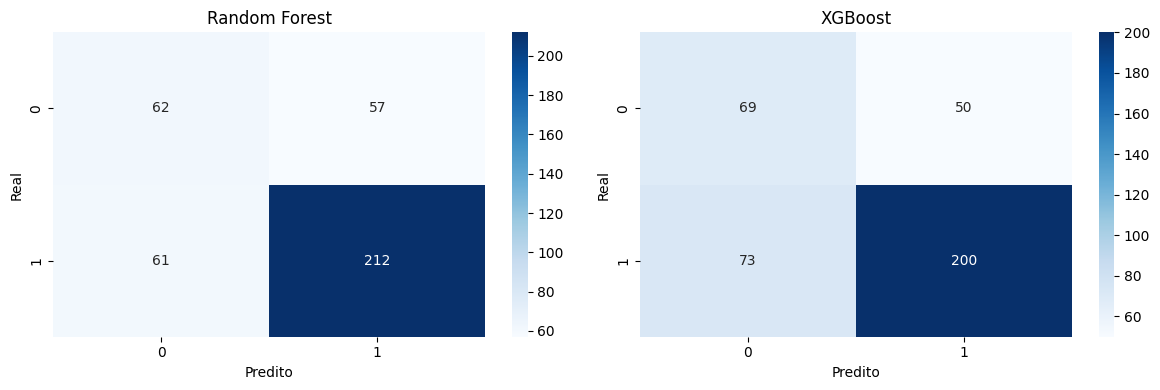

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Random Forest')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('XGBoost')
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()


**Gráficos da Importância de Atributos dos Modelos**

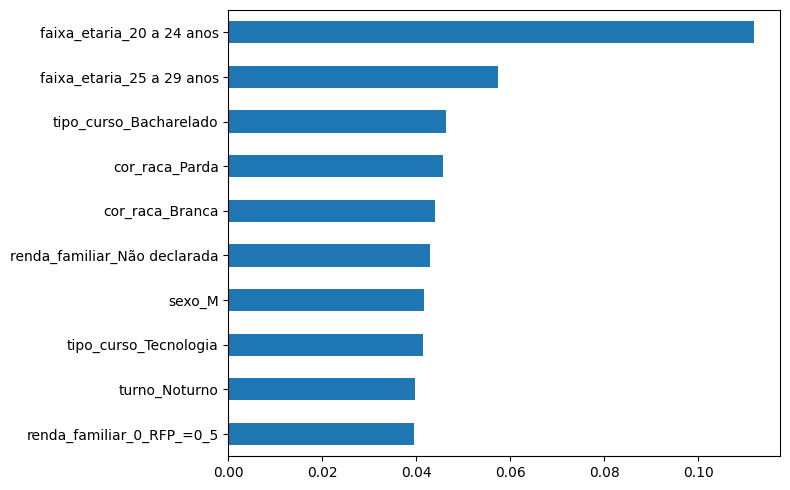

In [16]:
feat_imp_rf.head(10).sort_values().plot(kind='barh', figsize=(8, 5))
#plt.title('Top 10 Features — Random Forest')
plt.tight_layout()

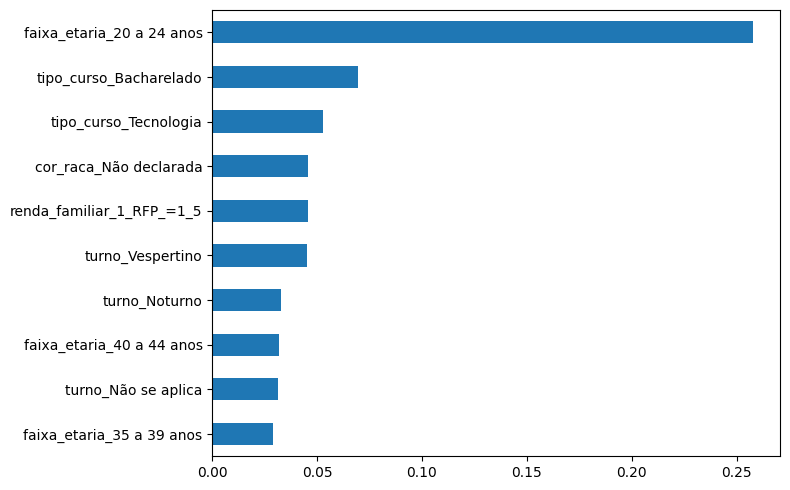

In [17]:
feat_imp_xgb.head(10).sort_values().plot(kind='barh', figsize=(8, 5))
#plt.title('Top 10 Features — XGBoost')
plt.tight_layout()